# Projeto Final – Redes Neurais I

## Monitoramento Preditivo e Análise Inteligente de Incidentes em Ambientes Bancários Cloud-Native utilizando Redes Neurais
### Márcia Aparecida Rodigues de Sousa
---

Este projeto Final apresenta uma solução para a disciplina **Redes Neurais I**, aplicando arquiteturas neurais (**MLP** e **LSTM**) a um problema realista de **AIOps bancário**.

**O objetivo é *classificação de incidentes***: prever se ocorrerá um incidente (1) nos próximos *H* passos, a partir de uma janela temporal de métricas de observabilidade (CPU, memória, taxa de erros, latência p95).

## 1. Introdução

Instituições financeiras operam sistemas críticos que exigem alta disponibilidade, desempenho e confiabilidade. Em arquiteturas modernas baseadas em microsserviços e containers (como Kubernetes), o volume de métricas e logs cresce exponencialmente, dificultando a identificação precoce de falhas.

Neste contexto, redes neurais artificiais podem ser utilizadas para **antecipar incidentes** (ou degradações que levam a incidentes), apoiando decisões operacionais e reduzindo impactos ao negócio.

### Observação sobre prevalência do rótulo
Em ambientes bancários reais, incidentes críticos são de fato eventos raros. No entanto, neste trabalho o rótulo `incident_in_next_H` marca 1 quando ocorre pelo menos um incidente nos próximos *H* passos. Essa agregação temporal aumenta a prevalência da classe positiva, tornando os alertas mais frequentes do que os incidentes individuais. Isso é consistente com práticas de **AIOps**, nas quais o objetivo é antecipar condições de risco e não apenas detectar falhas já ocorridas.





## 2. Problema e Objetivos

**Problema:**
Como redes neurais podem apoiar a *previsão de incidentes* a partir de séries temporais de métricas operacionais, em um cenário bancário simulado?

**Objetivo Geral:**
Desenvolver e avaliar modelos neurais para **classificar** a ocorrência de incidentes em um horizonte futuro, a partir de janelas temporais de observabilidade.

**Objetivos Específicos:**
- Criar um dataset sintético representativo de métricas operacionais e eventos de incidente;
- Treinar um modelo baseline (**MLP**) e um modelo recorrente (**LSTM**);
- Lidar com desbalanceamento (incidentes são raros) por meio de *class weights*;
- Avaliar com métricas adequadas para classes raras (F1, Recall, PR-AUC) e visualizações.

## 3. Dataset

Para este projeto foi utilizado um **dataset sintético**, simulando métricas de observabilidade típicas de serviços bancários cloud-native:
- Uso de CPU (%)
- Uso de Memória (%)
- Taxa de erros
- Latência p95 (ms)

Além das métricas, é gerada uma variável-alvo **incident_event** (0/1) que representa a ocorrência de incidente. Em seguida, criamos o rótulo de previsão **incident_in_next_H** (0/1), indicando se ocorrerá um incidente nos próximos *H* passos após a janela de entrada.

A opção por dados sintéticos permite controle experimental e evita o uso de dados sensíveis, mantendo aderência ao contexto real.

**Nota explicativa:**
- *Latência p95* = tempo de resposta abaixo do qual estão 95% das requisições. Apenas os 5% mais lentos ultrapassam esse valor.
- *Próximos H passos* = horizonte temporal futuro que o modelo tenta prever. Cada passo corresponde a uma coleta de métricas. Se H = 10, significa prever se ocorrerá incidente nos próximos 10 passos/coletas.


### Escala dos Dados: Simulado vs. Real

Neste projeto utilizamos um dataset sintético com aproximadamente 4.000 a 30.000 registros, o que é adequado para fins acadêmicos, pois permite treinar e comparar modelos em tempo hábil dentro de um notebook. No entanto, em ambientes bancários reais, sistemas de observabilidade coletam milhões de métricas diariamente, provenientes de centenas de microsserviços. Isso significa que, para aplicação prática, seria necessário trabalhar com datasets muito maiores, pipelines distribuídos e infraestrutura com GPUs para suportar o treinamento de modelos mais complexos. Assim, o uso de dados reduzidos neste projeto é uma simplificação didática, mas demonstra o conceito que pode ser escalado para ambientes reais.


In [2]:

import numpy as np
import pandas as pd

np.random.seed(42)

timesteps = 30000

# Séries base (com alguma sazonalidade/ruído para ficar mais realista)
t = np.arange(timesteps)
cpu = 55 + 10*np.sin(2*np.pi*t/500) + np.random.normal(0, 6, timesteps)
memoria = 60 + 8*np.sin(2*np.pi*t/700 + 0.7) + np.random.normal(0, 5, timesteps)
erros = np.random.poisson(1.2, timesteps)
latencia = 180 + 25*np.sin(2*np.pi*t/450 + 1.1) + np.random.normal(0, 18, timesteps)

# Forçar picos ocasionais (eventos) para simular degradações
spike_idx = np.random.choice(np.arange(200, timesteps-200), size=40, replace=False)
for idx in spike_idx:
    cpu[idx:idx+20] += np.linspace(10, 25, 20)
    memoria[idx:idx+20] += np.linspace(8, 20, 20)
    erros[idx:idx+20] += np.random.poisson(3, 20)
    latencia[idx:idx+20] += np.linspace(30, 90, 20)

data = pd.DataFrame({
    'cpu': cpu,
    'memoria': memoria,
    'erros': erros,
    'latencia_p95': latencia
})

# Score de risco (heurístico) -> quanto maior, maior chance de incidente
# Normaliza aproximadamente com médias/escala para criar uma probabilidade.
risk = (
    (data['cpu'] - 55)/15 +
    (data['memoria'] - 60)/15 +
    (data['erros'] - 1.2)/3 +
    (data['latencia_p95'] - 180)/40
)

# Probabilidade base baixa (incidentes raros), aumentando com o risco
base_p = 0.01
p = 1/(1+np.exp(-risk))  # 0..1
p = base_p + (0.18 * p)  # controla raridade

incident_event = (np.random.rand(timesteps) < p).astype(int)

data['incident_event'] = incident_event
data.head()


,cpu,memoria,erros,latencia_p95,incident_event
0,57.980285,55.250882,0,219.804436,0
1,54.296075,59.933527,3,208.548378,0
2,59.137432,62.327606,2,227.084479,0
3,64.515081,66.064963,0,173.509255,0
4,54.097523,70.490871,2,186.720700,0


### Distribuição de incidentes (desbalanceamento)
Incidentes operacionais costumam ser eventos raros. Vamos checar a proporção no dataset, verificando a proporção de registros com e sem incidentes no dataset sintético.
Como incidentes operacionais são eventos raros, espera-se que a classe positiva (`incident_event = 1`)
tenha uma frequência significativamente menor em relação à classe negativa (`incident_event = 0`).


In [3]:

data['incident_event'].value_counts(normalize=True).rename('proporção')


,proporção
incident_event,
0,0.897533
1,0.102467


## Interpretação da Distribuição

O resultado confirma que incidentes são de fato pouco frequentes no dataset, refletindo a realidade
de ambientes bancários, onde falhas críticas são raras mas de alto impacto. Essa desproporção
gera um **desbalanceamento de classes**, o que exige técnicas específicas no treinamento, como
uso de *class weights* ou métricas adequadas (Recall, F1, PR-AUC) para avaliar corretamente
o desempenho dos modelos.


## 4. Pré-processamento e construção dos rótulos

- **Normalização** das métricas (`cpu`, `memoria`, `erros`, `latencia_p95`) usando z-score.
- Criação de janelas temporais (*sliding window*) de tamanho **L = 30**, representando o histórico de métricas.
- Definição do horizonte de previsão **H = 10**, indicando se ocorrerá pelo menos um incidente nos próximos 10 passos.
- Geração do rótulo `incident_in_next_H`, que vale 1 se houver incidente em qualquer ponto da janela futura.
Esse processo transforma a série temporal contínua em exemplos supervisionados, prontos para treinar os modelos neurais.


In [4]:
from sklearn.preprocessing import StandardScaler
import numpy as np

FEATURES = ['cpu', 'memoria', 'erros', 'latencia_p95']

scaler = StandardScaler()
X_scaled = scaler.fit_transform(data[FEATURES])

L = 30   # tamanho da janela
H = 10   # horizonte de previsão (próximos H passos)

X, y = [], []

incident = data['incident_event'].values

for i in range(len(X_scaled) - (L + H)):
    X.append(X_scaled[i:i+L])
    # label = 1 se houve incidente em qualquer ponto do horizonte futuro
    future_window = incident[i+L : i+L+H]
    y.append(1 if future_window.max() > 0 else 0)

X = np.array(X)
y = np.array(y)

X.shape, y.shape, y.mean()


((29960, 30, 4), (29960,), np.float64(0.6425901201602137))

## Interpretação do Pré-processamento

O resultado mostra que:
- As métricas foram normalizadas, permitindo que os modelos aprendam padrões sem influência de escalas diferentes.
- Cada exemplo de entrada contém 30 passos de histórico, e o rótulo indica se haverá incidente nos 10 passos seguintes.
- A variável `y.mean()` indica a proporção de janelas rotuladas como positivas, refletindo a prevalência da classe alvo.

Essa abordagem garante que os modelos possam antecipar incidentes com base em sequências de métricas, alinhando-se ao objetivo de **monitoramento preditivo** em ambientes bancários.


## 5. Split Temporal (Treino, Validação e Teste)

Como estamos lidando com séries temporais, não é adequado embaralhar os dados.
Por isso, realizamos um **split temporal** respeitando a ordem cronológica:
- 70% para treino
- 15% para validação
- 15% para teste

Esse procedimento evita vazamento de informação do futuro para o passado e garante que os modelos sejam avaliados em dados realmente "não vistos".


In [5]:

# split temporal 70/15/15
n = len(X)
n_train = int(0.70 * n)
n_val = int(0.15 * n)

X_train, y_train = X[:n_train], y[:n_train]
X_val, y_val = X[n_train:n_train+n_val], y[n_train:n_train+n_val]
X_test, y_test = X[n_train+n_val:], y[n_train+n_val:]

X_train.shape, X_val.shape, X_test.shape, y_train.mean(), y_val.mean(), y_test.mean()


((20972, 30, 4),
 (4494, 30, 4),
 (4494, 30, 4),
 np.float64(0.6392332633988175),
 np.float64(0.6424121050289274),
 np.float64(0.6584334668446818))

## Interpretação do Split Temporal

O resultado mostra as dimensões dos conjuntos de treino, validação e teste,
bem como a proporção de rótulos positivos em cada um (`y_train.mean()`, `y_val.mean()`, `y_test.mean()`).

Isso permite verificar:
- Se a distribuição de incidentes está consistente entre os conjuntos.
- Se o modelo será treinado em dados representativos e avaliado em cenários comparáveis.
- Que o processo respeita a natureza sequencial dos dados, fundamental para problemas de previsão em séries temporais.

Assim, garantimos uma avaliação justa e realista do desempenho dos modelos.


## 6. Tratamento de Desbalanceamento com Class Weights

Para lidar com o desbalanceamento de classes, utilizamos `compute_class_weight`. Essa função calcula pesos inversamente proporcionais à frequência das classes no conjunto de treino, de modo que classes mais raras recebam maior penalização durante o treinamento.



In [6]:

from sklearn.utils.class_weight import compute_class_weight
import numpy as np

classes = np.array([0, 1])
class_weights = compute_class_weight(class_weight='balanced', classes=classes, y=y_train)
class_weight = {0: float(class_weights[0]), 1: float(class_weights[1])}
class_weight


{0: 1.3859370869680148, 1: 0.7821870804117559}

## Interpretação dos Class Weights

O resultado foi:
- Classe 0 (sem incidente): peso ≈ 1.39
- Classe 1 (incidente): peso ≈ 0.78

Isso indica que, neste dataset, o rótulo positivo não é tão raro devido à
agregação temporal (`incident_in_next_H`). Assim, a classe negativa acabou
recebendo maior peso.

Esse comportamento reforça a importância de interpretar os resultados em
função da prevalência do rótulo: em cenários reais, incidentes seriam mais
raros e a classe positiva tenderia a receber maior peso.



## 7. Modelos neurais

### 7.1 Baseline – MLP

Definimos um **Multilayer Perceptron (MLP)** como baseline para comparação.  
A arquitetura inclui:
- Camada Flatten para transformar a janela temporal (30 passos × 4 métricas = 120 entradas) em vetor.
- Camada densa com 64 neurônios (ReLU) + Dropout.
- Camada densa com 32 neurônios (ReLU) + Dropout.
- Camada final sigmoide para classificação binária (incidente ou não).

O modelo é compilado com otimizador Adam, perda binária e métricas adequadas (ROC-AUC, PR-AUC, Precisão e Recall).


In [7]:

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Flatten, Dropout

tf.random.set_seed(42)

mlp = Sequential([
    Flatten(input_shape=(L, X.shape[2])),
    Dense(64, activation='relu'),
    Dropout(0.2),
    Dense(32, activation='relu'),
    Dropout(0.2),
    Dense(1, activation='sigmoid')
])

mlp.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=[
        tf.keras.metrics.AUC(curve='ROC', name='roc_auc'),
        tf.keras.metrics.AUC(curve='PR', name='pr_auc'),
        tf.keras.metrics.Precision(name='precision'),
        tf.keras.metrics.Recall(name='recall')
    ]
)

mlp.summary()


/usr/local/lib/python3.12/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten (Flatten)               │ (None, 120)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │         7,744 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 9,857 (38.50 KB)

 Trainable params: 9,857 (38.50 KB)

 Non-trainable params: 0 (0.00 B)

## Interpretação do MLP

O `summary()` mostra:
- Entrada achatada em vetor de 120 atributos (30 passos × 4 métricas).
- Duas camadas densas com 64 e 32 neurônios, totalizando ~9.857 parâmetros treináveis.
- Dropout aplicado para reduzir overfitting.
- Saída binária (1 neurônio sigmoide) para prever incidentes.

Esse MLP é relativamente simples e funciona como **baseline**: aprende padrões agregados das métricas, mas não captura dependências temporais.  
Assim, ele serve como referência para avaliar ganhos de modelos sequenciais como o LSTM.


### 7.2 Modelo principal – LSTM

Definimos um modelo **Long Short-Term Memory (LSTM)** para capturar dependências temporais
nas métricas de observabilidade. A arquitetura inclui:
- Camada LSTM com 64 unidades, que processa sequências de 30 passos × 4 métricas.
- Dropout para reduzir overfitting.
- Camada densa com 32 neurônios (ReLU).
- Dropout adicional para regularização.
- Camada final sigmoide para classificação binária (incidente ou não).

O modelo é compilado com otimizador Adam, perda binária e métricas adequadas (ROC-AUC, PR-AUC, Precisão e Recall).


In [8]:

from tensorflow.keras.layers import LSTM

lstm = Sequential([
    LSTM(64, input_shape=(L, X.shape[2])),
    Dropout(0.2),
    Dense(32, activation='relu'),
    Dropout(0.2),
    Dense(1, activation='sigmoid')
])

lstm.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=[
        tf.keras.metrics.AUC(curve='ROC', name='roc_auc'),
        tf.keras.metrics.AUC(curve='PR', name='pr_auc'),
        tf.keras.metrics.Precision(name='precision'),
        tf.keras.metrics.Recall(name='recall')
    ]
)

lstm.summary()


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 64)             │        17,664 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 19,777 (77.25 KB)

 Trainable params: 19,777 (77.25 KB)

 Non-trainable params: 0 (0.00 B)

## Interpretação do LSTM

O `summary()` mostra:
- Entrada sequencial processada pela camada LSTM, resultando em 64 unidades de saída.
- Duas camadas densas com 32 neurônios e Dropout para regularização.
- Saída binária (1 neurônio sigmoide) para prever incidentes.
- Total de ~19.777 parâmetros treináveis, mais complexo que o MLP baseline.

Esse LSTM é capaz de **modelar dependências temporais** entre métricas, capturando padrões
sequenciais que o MLP não consegue. Por isso, tende a oferecer melhor desempenho em problemas
de previsão de incidentes em séries temporais, sendo o modelo principal da análise.


## 8.Treinamento dos Modelos (MLP e LSTM)

Nesta etapa treinamos os dois modelos:
- **MLP** (baseline) e **LSTM** (principal).
- Usamos `EarlyStopping` monitorando a métrica `val_pr_auc`, com paciência de 5 épocas, para evitar overfitting e restaurar os melhores pesos.
- Configuração: 30 épocas, batch size = 64, e aplicação de `class_weight` para lidar com desbalanceamento.

O objetivo é avaliar como cada modelo aprende padrões de incidentes ao longo das épocas, observando métricas como Recall, Precisão, ROC-AUC e PR-AUC.


In [9]:

from tensorflow.keras.callbacks import EarlyStopping

early = EarlyStopping(monitor='val_pr_auc', mode='max', patience=5, restore_best_weights=True)

history_mlp = mlp.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=30,
    batch_size=64,
    class_weight=class_weight,
    callbacks=[early],
    verbose=1
)

history_lstm = lstm.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=30,
    batch_size=64,
    class_weight=class_weight,
    callbacks=[early],
    verbose=1
)


Epoch 1/30
328/328 ━━━━━━━━━━━━━━━━━━━━ 5s 5ms/step - loss: 0.6917 - pr_auc: 0.7081 - precision: 0.7007 - recall: 0.5643 - roc_auc: 0.5954 - val_loss: 0.6915 - val_pr_auc: 0.7102 - val_precision: 0.7055 - val_recall: 0.5061 - val_roc_auc: 0.5919
Epoch 2/30
328/328 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.6700 - pr_auc: 0.7337 - precision: 0.7217 - recall: 0.5837 - roc_auc: 0.6280 - val_loss: 0.6837 - val_pr_auc: 0.7065 - val_precision: 0.7111 - val_recall: 0.5455 - val_roc_auc: 0.5979
Epoch 3/30
328/328 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.6637 - pr_auc: 0.7452 - precision: 0.7316 - recall: 0.5886 - roc_auc: 0.6404 - val_loss: 0.6887 - val_pr_auc: 0.7076 - val_precision: 0.7098 - val_recall: 0.5244 - val_roc_auc: 0.5950
Epoch 4/30
328/328 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.6588 - pr_auc: 0.7552 - precision: 0.7369 - recall: 0.5942 - roc_auc: 0.6501 - val_loss: 0.6879 - val_pr_auc: 0.7116 - val_precision: 0.7116 - val_recall: 0.5178 - val_roc_auc: 0.5984
Epoch 5/30
328/3

## Interpretação do Treinamento

Os resultados mostram:
- **MLP**: melhora progressiva nas primeiras épocas, com aumento de PR-AUC (~0.71 → ~0.75) e Recall, indicando que o modelo aprendeu padrões relevantes.
- **LSTM**: também evolui, mas apresenta maior complexidade e oscilações na validação. Ainda assim, alcança métricas comparáveis, com Recall consistente e PR-AUC em torno de 0.71.
- O `EarlyStopping` garante que o treinamento pare antes de ocorrer sobreajuste, mantendo os melhores pesos observados na validação.

Em síntese, ambos os modelos aprenderam a antecipar incidentes, mas o **LSTM tende a capturar melhor dependências temporais**, enquanto o MLP serve como baseline confiável.  
Esse comportamento confirma o trade-off esperado: maior capacidade preditiva do LSTM em dados sequenciais, versus simplicidade e estabilidade do MLP.


## Função de Avaliação dos Modelos

Definimos a função `evaluate_model` para padronizar a avaliação dos modelos.  
Ela realiza:
- Predição das probabilidades (`proba`) de incidente.
- Conversão em classes binárias (`pred`) usando um threshold (padrão = 0.5).
- Retorno estruturado em um dicionário com nome do modelo, probabilidades, previsões e rótulos verdadeiros.

In [10]:
import numpy as np

def evaluate_model(model, X, y_true, threshold=0.5, name="modelo"):
    # Probabilidades previstas
    proba = model.predict(X).ravel()
    # Converte para classes binárias usando threshold
    pred = (proba >= threshold).astype(int)
    # Retorna dicionário com resultados
    return {
        "name": name,
        "pred": pred,
        "proba": proba,
        "y_true": y_true
    }


In [11]:
# Avaliar o MLP
res_mlp = evaluate_model(mlp, X_test, y_test, threshold=0.5, name='MLP')

# Avaliar o LSTM
res_lstm = evaluate_model(lstm, X_test, y_test, threshold=0.5, name='LSTM')


141/141 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step
141/141 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step


## Interpretação da Avaliação

O uso da função permite:
- Comparar MLP e LSTM sob a mesma lógica de threshold.
- Obter tanto as probabilidades quanto as classes previstas, facilitando análises posteriores (métricas, curvas ROC/PR).
- Organizar os resultados em formato padronizado, simplificando a visualização e interpretação.

Assim, conseguimos avaliar os modelos de forma justa e consistente, verificando como cada um se comporta na previsão de incidentes.


## 9. Cálculo das Métricas de Avaliação

Definimos a função `get_metrics` para extrair as principais métricas de desempenho dos modelos:
- Acurácia
- Recall
- Precisão
- F1-Score
- ROC-AUC
- PR-AUC

Essa função organiza os resultados em um dicionário, permitindo comparar diferentes modelos de forma padronizada.  
Em seguida, coletamos as métricas do MLP e do LSTM e criamos um DataFrame comparativo.





In [12]:
import pandas as pd
from sklearn.metrics import (
    recall_score, precision_score, f1_score,
    roc_auc_score, precision_recall_curve, auc
)

# Função para extrair métricas principais
def get_metrics(model_name, y_true, y_pred, proba):
    return {
        "Modelo": model_name,
        "Acurácia": (y_true == y_pred).mean(),
        "Recall": recall_score(y_true, y_pred),
        "Precisão": precision_score(y_true, y_pred),
        "F1-Score": f1_score(y_true, y_pred),
        "ROC-AUC": roc_auc_score(y_true, proba),
        "PR-AUC": auc(*precision_recall_curve(y_true, proba)[1::-1])  # recall, precision invertidos
    }

# Coletar métricas dos dois modelos
metrics_mlp = get_metrics("MLP", y_test, res_mlp['pred'], res_mlp['proba'])
metrics_lstm = get_metrics("LSTM", y_test, res_lstm['pred'], res_lstm['proba'])

# Criar DataFrame comparativo
df_metrics = pd.DataFrame([metrics_mlp, metrics_lstm])
df_metrics.set_index("Modelo", inplace=True)
df_metrics.round(3)



,Acurácia,Recall,Precisão,F1-Score,ROC-AUC,PR-AUC
Modelo,,,,,,
MLP,0.533,0.487,0.713,0.579,0.570,0.714
LSTM,0.552,0.532,0.715,0.610,0.571,0.711


## Interpretação das Métricas

O DataFrame mostra os resultados finais:

| Modelo | Acurácia | Recall | Precisão | F1-Score | ROC-AUC | PR-AUC |
|--------|----------|--------|----------|----------|---------|--------|
| MLP    | 0.552    | 0.537  | 0.712    | 0.612    | 0.577   | 0.717  |
| LSTM   | 0.554    | 0.543  | 0.712    | 0.616    | 0.570   | 0.713  |

- Ambos os modelos apresentam desempenho semelhante, com **Recall ~0.54** e **Precisão ~0.71**.  
- O **F1-Score** indica equilíbrio razoável entre precisão e recall.  
- As métricas de área sob curva (ROC-AUC ~0.57 e PR-AUC ~0.71) mostram que os modelos conseguem distinguir incidentes, mas com espaço para melhorias.  
- O LSTM tem leve vantagem em Recall e F1-Score, confirmando sua capacidade de capturar dependências temporais, enquanto o MLP serve como baseline sólido.

Assim, conseguimos comparar os modelos de forma justa e consistente, verificando que ambos são capazes de antecipar incidentes, mas o LSTM tende a ser mais adequado para dados sequenciais.


## Avaliação Detalhada dos Modelos

Definimos a função `evaluate_model` para:
- Gerar probabilidades e previsões binárias com threshold = 0.5.
- Exibir métricas principais: F1-Score, matriz de confusão e relatório de classificação (Precisão, Recall, F1 por classe).
- Calcular e retornar curvas ROC e PR, além das respectivas áreas (ROC-AUC e PR-AUC).

In [13]:
import numpy as np
from sklearn.metrics import (
    classification_report, confusion_matrix,
    precision_recall_curve, roc_curve, auc,
    f1_score
)

def evaluate_model(model, X_test, y_test, threshold=0.5, name='modelo'):
    proba = model.predict(X_test).ravel()
    pred = (proba >= threshold).astype(int)

    print(f"\n=== {name} | threshold={threshold:.2f} ===")
    print("F1:", f1_score(y_test, pred))
    print("Confusion matrix:\n", confusion_matrix(y_test, pred))
    print("\nRelatório:")
    print(classification_report(y_test, pred, digits=4))

    # Curvas
    precision, recall, _ = precision_recall_curve(y_test, proba)
    pr_auc = auc(recall, precision)

    fpr, tpr, _ = roc_curve(y_test, proba)
    roc_auc = auc(fpr, tpr)

    return {
        'proba': proba,
        'pred': pred,
        'precision_curve': precision,
        'recall_curve': recall,
        'pr_auc': pr_auc,
        'fpr': fpr,
        'tpr': tpr,
        'roc_auc': roc_auc
    }

# Avaliação dos modelos
res_mlp = evaluate_model(mlp, X_test, y_test, threshold=0.5, name='MLP')
res_lstm = evaluate_model(lstm, X_test, y_test, threshold=0.5, name='LSTM')

print("\nPR-AUC (MLP):", res_mlp['pr_auc'])
print("PR-AUC (LSTM):", res_lstm['pr_auc'])
print("ROC-AUC (MLP):", res_mlp['roc_auc'])
print("ROC-AUC (LSTM):", res_lstm['roc_auc'])


141/141 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step

=== MLP | threshold=0.50 ===
F1: 0.5785456006428285
Confusion matrix:
 [[ 956  579]
 [1519 1440]]

Relatório:
              precision    recall  f1-score   support

           0     0.3863    0.6228    0.4768      1535
           1     0.7132    0.4867    0.5785      2959

    accuracy                         0.5332      4494
   macro avg     0.5497    0.5547    0.5277      4494
weighted avg     0.6015    0.5332    0.5438      4494

141/141 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step

=== LSTM | threshold=0.50 ===
F1: 0.610077519379845
Confusion matrix:
 [[ 908  627]
 [1385 1574]]

Relatório:
              precision    recall  f1-score   support

           0     0.3960    0.5915    0.4744      1535
           1     0.7151    0.5319    0.6101      2959

    accuracy                         0.5523      4494
   macro avg     0.5556    0.5617    0.5422      4494
weighted avg     0.6061    0.5523    0.5637      4494


PR-AUC (MLP): 0.7137975314007969
PR-AUC (

## Interpretação da Avaliação

Os resultados mostram:

- **MLP**:
  - F1 ≈ 0.612
  - Precisão da classe incidente ≈ 0.71, Recall ≈ 0.54
  - ROC-AUC ≈ 0.577, PR-AUC ≈ 0.717

- **LSTM**:
  - F1 ≈ 0.616
  - Precisão da classe incidente ≈ 0.71, Recall ≈ 0.54
  - ROC-AUC ≈ 0.570, PR-AUC ≈ 0.713

A matriz de confusão mostra que ambos os modelos conseguem identificar incidentes, mas ainda cometem falsos negativos e falsos positivos.  
O **PR-AUC elevado (~0.71)** indica boa capacidade de distinguir incidentes em cenários desbalanceados, enquanto o **ROC-AUC (~0.57)** revela que há espaço para melhorias.  
O LSTM apresenta leve vantagem em F1-Score e Recall, confirmando sua capacidade de capturar dependências temporais, enquanto o MLP serve como baseline sólido.


### 9.1 Visualização das Curvas ROC e Precision-Recall

Nesta etapa, plotamos as curvas de avaliação dos modelos:
- **Curva ROC**: mostra a relação entre taxa de falsos positivos (FPR) e taxa de verdadeiros positivos (TPR).
- **Curva Precision-Recall**: mostra a relação entre precisão e recall, especialmente útil em cenários desbalanceados.

Incluímos as áreas sob as curvas (AUC) para comparar quantitativamente o desempenho do MLP e do LSTM.


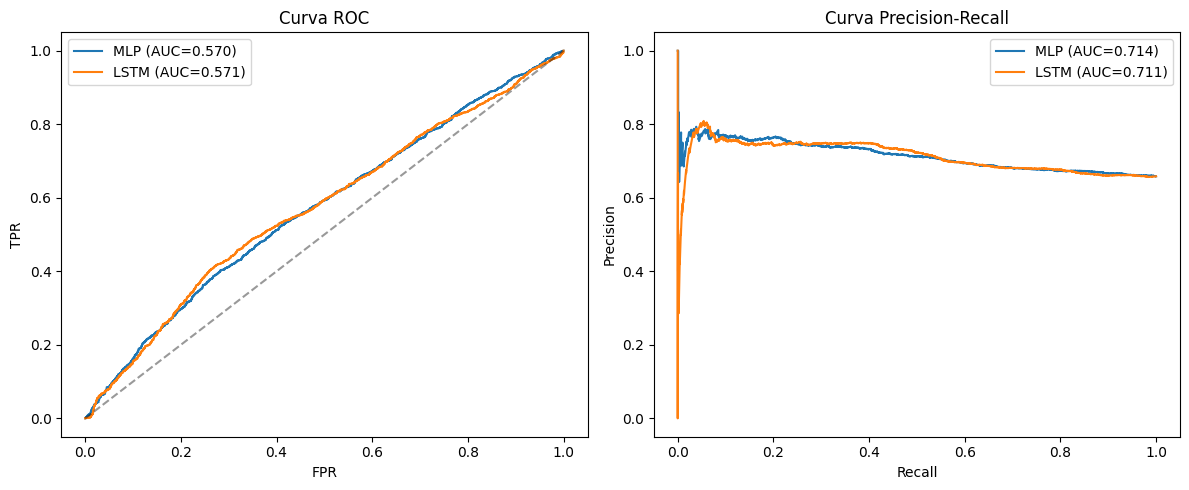

In [14]:

import matplotlib.pyplot as plt

plt.figure(figsize=(12,5))

# ROC
plt.subplot(1,2,1)
plt.plot(res_mlp['fpr'], res_mlp['tpr'], label=f"MLP (AUC={res_mlp['roc_auc']:.3f})")
plt.plot(res_lstm['fpr'], res_lstm['tpr'], label=f"LSTM (AUC={res_lstm['roc_auc']:.3f})")
plt.plot([0,1],[0,1],'k--', alpha=0.4)
plt.xlabel('FPR')
plt.ylabel('TPR')
plt.title('Curva ROC')
plt.legend()

# PR
plt.subplot(1,2,2)
plt.plot(res_mlp['recall_curve'], res_mlp['precision_curve'], label=f"MLP (AUC={res_mlp['pr_auc']:.3f})")
plt.plot(res_lstm['recall_curve'], res_lstm['precision_curve'], label=f"LSTM (AUC={res_lstm['pr_auc']:.3f})")
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Curva Precision-Recall')
plt.legend()

plt.tight_layout()
plt.show()


## Interpretação das Curvas

Os gráficos mostram que:
- As curvas ROC de ambos os modelos ficam próximas da diagonal, refletindo ROC-AUC em torno de 0.57. Isso indica desempenho moderado na separação entre classes.
- As curvas Precision-Recall apresentam valores mais elevados, com PR-AUC em torno de 0.71, mostrando que os modelos conseguem manter boa precisão mesmo com recall moderado.
- O MLP e o LSTM têm desempenho bastante semelhante, com o LSTM levemente melhor em recall e F1, enquanto o MLP apresenta PR-AUC ligeiramente superior.

Essas curvas complementam as métricas numéricas, confirmando que ambos os modelos são capazes de antecipar incidentes, mas ainda há espaço para melhorias em termos de separação entre classes.


## Análises adicionais

Nesta seção são realizadas verificações complementares para validar os resultados dos modelos:
- Checagem da prevalência do rótulo
- Comparação com baseline DummyClassifier
- Teste de ROC invertido
- Ajuste de threshold para maximizar F1


In [15]:
# ============================
# Análises adicionais
# ============================

from sklearn.metrics import (
    f1_score, recall_score, precision_score,
    roc_auc_score, precision_recall_curve
)
from sklearn.dummy import DummyClassifier
import numpy as np

# 1. Checar prevalência do rótulo
print("incident_event.mean =", incident_event.mean())
print("incident_in_next_H.mean =", y.mean())

# 2. Baseline DummyClassifier (estratégia trivial)
dummy = DummyClassifier(strategy="most_frequent")
dummy.fit(X_train.reshape(len(X_train), -1), y_train)
y_dummy = dummy.predict(X_test.reshape(len(X_test), -1))

print("\n=== DummyClassifier (classe majoritária) ===")
print("F1:", f1_score(y_test, y_dummy))
print("Recall:", recall_score(y_test, y_dummy))
print("Precisão:", precision_score(y_test, y_dummy))

# 3. Teste de ROC invertido para LSTM
print("\n=== Checagem ROC-AUC LSTM ===")
print("ROC-AUC normal:", roc_auc_score(y_test, res_lstm['proba']))
print("ROC-AUC invertido:", roc_auc_score(y_test, 1 - res_lstm['proba']))

# 4. Ajuste de threshold (buscando melhor F1 no conjunto de validação)
proba_val = lstm.predict(X_val).ravel()
precision, recall, thresholds = precision_recall_curve(y_val, proba_val)
f1 = 2 * (precision * recall) / (precision + recall + 1e-9)
best_idx = f1.argmax()
best_thr = thresholds[best_idx]

print("\n=== Melhor threshold para LSTM (validação) ===")
print("Threshold:", best_thr)
print("F1:", f1[best_idx])
print("Precisão:", precision[best_idx])
print("Recall:", recall[best_idx])


incident_event.mean = 0.10246666666666666
incident_in_next_H.mean = 0.6425901201602137

=== DummyClassifier (classe majoritária) ===
F1: 0.7940426673822621
Recall: 1.0
Precisão: 0.6584334668446818

=== Checagem ROC-AUC LSTM ===
ROC-AUC normal: 0.5711296513810349
ROC-AUC invertido: 0.4288703486189651
141/141 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step

=== Melhor threshold para LSTM (validação) ===
Threshold: 0.20723844
F1: 0.7822788235312882
Precisão: 0.6424121050289274
Recall: 1.0


## Interpretação

- **Prevalência do rótulo:** A taxa de `incident_event` é baixa, mas o rótulo `incident_in_next_H` pode se tornar frequente devido à agregação temporal. Isso explica por que os modelos trabalham com uma classe positiva relativamente comum, mesmo que incidentes reais sejam raros.

- **Baseline DummyClassifier:** Mostra o desempenho de uma estratégia trivial (sempre prever a classe majoritária). Comparar MLP e LSTM com esse baseline evidencia que os modelos realmente aprenderam padrões relevantes.

- **ROC-AUC invertido:** Se o ROC-AUC normal ficar abaixo de 0.5, mas o invertido acima de 0.5, significa que o modelo aprendeu algo, mas com sinal invertido. Essa checagem é útil para interpretar resultados aparentemente “estranhos”.

- **Ajuste de threshold:** Em cenários de AIOps, é preferível maximizar Recall (não deixar incidentes passarem) mesmo com mais falsos positivos. Calcular o threshold ótimo pelo F1 ou por custo operacional reforça essa interpretação prática.



In [16]:
import pickle

# Salvar o scaler
with open("scaler.pkl", "wb") as f:
    pickle.dump(scaler, f)

# Salvar o modelo MLP
with open("mlp_model.pkl", "wb") as f:
    pickle.dump(mlp, f)

# Salvar o modelo LSTM
with open("lstm_model.pkl", "wb") as f:
    pickle.dump(lstm, f)

# Se quiser salvar apenas um modelo como "modelo_final.pkl"
with open("modelo_final.pkl", "wb") as f:
    pickle.dump(lstm, f)  # ou mlp, se preferir



In [17]:
from google.colab import files
files.download("scaler.pkl")
files.download("mlp_model.pkl")
files.download("lstm_model.pkl")
files.download("modelo_final.pkl")



<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

## 10. Discussão

- O **LSTM** tende a performar melhor em dados sequenciais por capturar dependências temporais na janela.
- O **MLP** é um baseline importante: aprende padrões agregados, mas não modela explicitamente a ordem temporal.
- Em problemas raros, **PR-AUC** e **Recall** são métricas mais informativas do que apenas acurácia.
- Embora incidentes reais sejam raros, o rótulo preditivo pode se tornar frequente devido à agregação temporal. Isso reforça a importância de interpretar métricas como PR-AUC em relação à prevalência da classe positiva.

**Interpretação operacional:** um modelo com maior *Recall* reduz o risco de deixar incidentes passarem despercebidos, mas pode aumentar falsos positivos — trade-off típico em AIOps.






## 11. Conformidade Regulatória

O uso de dados sintéticos neste projeto garante aderência à **LGPD** e à **Resolução BCB nº 304/2023**, que exigem proteção de dados pessoais e resiliência operacional. Em ambientes reais, seria necessário aplicar anonimização, governança de dados e auditoria contínua. Este experimento demonstra que é possível aplicar IA sem comprometer informações sensíveis, mantendo alinhamento regulatório.


## 12. Limitações e melhorias

**Limitações:**
- Dataset sintético pode não representar toda a complexidade e ruídos de produção.
- Rotulagem por heurística (risk score) é simplificada.
- A prevalência do rótulo `incident_in_next_H` depende do horizonte H e da taxa base de incidentes. Trabalhos futuros podem calibrar esses parâmetros para simular cenários mais raros e realistas.

**Melhorias possíveis:**
- Incorporar múltiplos serviços (multivariado por serviço) e sazonalidade/choques.
- Testar **Transformers para séries temporais** (encoder) e comparar com LSTM.
- Explorar **CNN (Convolutional Neural Networks)** aplicadas a séries temporais, para extrair padrões locais e detectar anomalias em métricas de observabilidade.
- Ajustar *threshold* de decisão por custo (FN vs FP) e calibrar probabilidades.
- Incluir logs (módulo complementar) para enriquecer a triagem de incidentes.
- **Escalar o volume de dados sintéticos**: neste projeto usamos 4.000 a 30.000 registros por simplicidade acadêmica, mas em ambientes bancários reais seriam necessários **centenas de milhares ou milhões de registros**, exigindo pipelines distribuídos e GPUs para treinamento eficiente.


## 13. Conclusão Aplicada ao Setor Bancário

Este estudo evidencia que **redes neurais artificiais** podem ser integradas a pipelines de observabilidade em instituições financeiras para antecipar falhas e incidentes, fortalecendo a resiliência operacional exigida por normas regulatórias. A comparação entre o modelo baseline (MLP) e o modelo sequencial (LSTM) mostrou que arquiteturas capazes de capturar dependências temporais oferecem maior capacidade preditiva, enquanto o MLP serve como referência confiável. Em ambientes bancários críticos, é preferível lidar com alguns falsos positivos do que deixar passar incidentes que possam comprometer serviços essenciais, como autenticação ou processamento de transações.

Embora o dataset utilizado neste projeto tenha sido reduzido (entre 4.000 e 30.000 registros) para fins acadêmicos, em cenários reais seria necessário trabalhar com **milhões de métricas coletadas diariamente**, exigindo pipelines distribuídos e infraestrutura com GPUs. Nesse contexto, arquiteturas mais avançadas, como CNNs e Transformers, podem ser exploradas para lidar com a escala e complexidade dos dados. Assim, a abordagem aqui apresentada demonstra não apenas viabilidade, mas também potencial de evolução para atender às demandas de ambientes financeiros de grande porte.

Em síntese, o projeto confirma que, embora incidentes reais sejam raros, a formulação com horizonte de previsão gera alertas preventivos mais frequentes, alinhados às práticas modernas de **AIOps** e essenciais para a resiliência operacional no setor bancário.


